In [1]:
import kagglehub
path = kagglehub.dataset_download("anandhuh/latest-covid19-india-statewise-data")

100%|██████████| 1.34k/1.34k [00:00<00:00, 1.84MB/s]

Extracting files...


In [2]:
import os
import pandas as pd

# List files in the downloaded path
files = os.listdir(path)
print("Files in the downloaded dataset directory:", files)

Files in the downloaded dataset directory: ['Latest Covid-19 India Status.csv']


In [5]:
# Assuming the main data file is 'Latest Covid-19 India Status.csv'
# We need to construct the full path to the CSV file
csv_file_name = 'Latest Covid-19 India Status.csv'
full_csv_path = os.path.join(path, csv_file_name)

# Load the dataset into a pandas DataFrame
df = pd.read_csv(full_csv_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,State/UTs,Total Cases,Active,Discharged,Deaths,Active Ratio,Discharge Ratio,Death Ratio,Population
0,Andaman and Nicobar,10766,0,10637,129,0.0,98.80,1.20,100896618
1,Andhra Pradesh,2340676,0,2325943,14733,0.0,99.37,0.63,128500364
2,Arunachal Pradesh,67049,0,66753,296,0.0,99.56,0.44,658019
3,Assam,746159,5,738119,8035,0.0,98.92,1.08,290492
4,Bihar,855267,1,842952,12314,0.0,98.56,1.44,40100376


In [6]:
df = pd.read_csv(full_csv_path)
display(df.head())
df.info()

,State/UTs,Total Cases,Active,Discharged,Deaths,Active Ratio,Discharge Ratio,Death Ratio,Population
0,Andaman and Nicobar,10766,0,10637,129,0.0,98.80,1.20,100896618
1,Andhra Pradesh,2340676,0,2325943,14733,0.0,99.37,0.63,128500364
2,Arunachal Pradesh,67049,0,66753,296,0.0,99.56,0.44,658019
3,Assam,746159,5,738119,8035,0.0,98.92,1.08,290492
4,Bihar,855267,1,842952,12314,0.0,98.56,1.44,40100376


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   State/UTs        36 non-null     object 
 1   Total Cases      36 non-null     int64  
 2   Active           36 non-null     int64  
 3   Discharged       36 non-null     int64  
 4   Deaths           36 non-null     int64  
 5   Active Ratio     36 non-null     float64
 6   Discharge Ratio  36 non-null     float64
 7   Death Ratio      36 non-null     float64
 8   Population       36 non-null     int64  
dtypes: float64(3), int64(5), object(1)
memory usage: 2.7+ KB


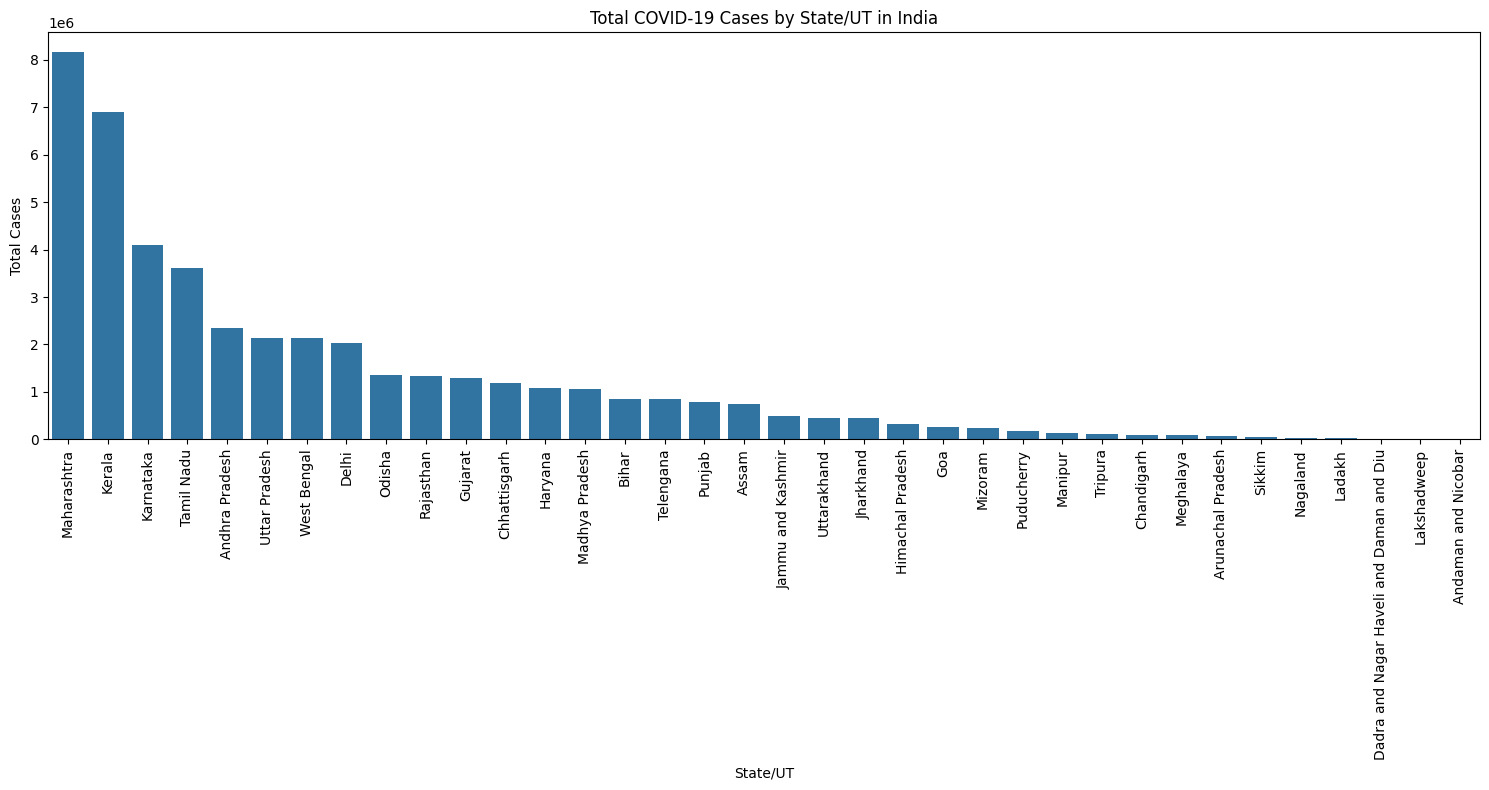

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort data by 'Total Cases' for better visualization
df_sorted_cases = df.sort_values(by='Total Cases', ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x='State/UTs', y='Total Cases', data=df_sorted_cases)
plt.xticks(rotation=90)
plt.title('Total COVID-19 Cases by State/UT in India')
plt.xlabel('State/UT')
plt.ylabel('Total Cases')
plt.tight_layout()
plt.show()

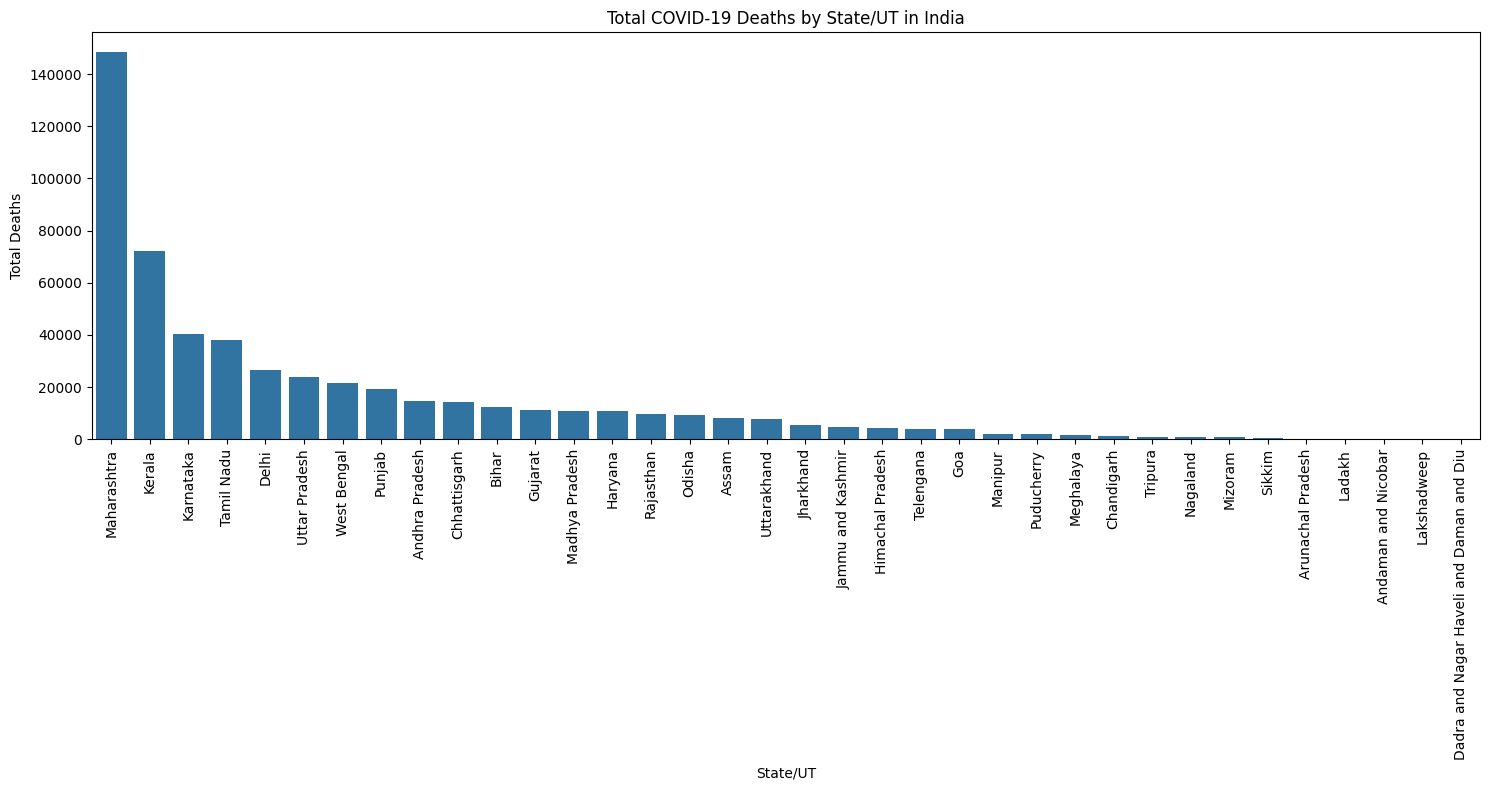

In [8]:
# Sort data by 'Deaths' for better visualization
df_sorted_deaths = df.sort_values(by='Deaths', ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x='State/UTs', y='Deaths', data=df_sorted_deaths)
plt.xticks(rotation=90)
plt.title('Total COVID-19 Deaths by State/UT in India')
plt.xlabel('State/UT')
plt.ylabel('Total Deaths')
plt.tight_layout()
plt.show()

### Death Case Ratio per State

Let's calculate the death case ratio for each state. The `Death Ratio` column in the dataset already provides this information, so we'll display it and then visualize it using a bar plot.

Top 10 States/UTs by Death Ratio:


,State/UTs,Total Cases,Deaths,Death Ratio
27,Punjab,793644,19338,2.44
24,Nagaland,36033,782,2.17
20,Maharashtra,8171048,148558,1.82
34,Uttarakhand,452571,7768,1.72
22,Meghalaya,96983,1628,1.68
21,Manipur,140034,2149,1.53
9,Goa,263346,4014,1.52
4,Bihar,855267,12314,1.44
8,Delhi,2040910,26666,1.31
12,Himachal Pradesh,322905,4241,1.31


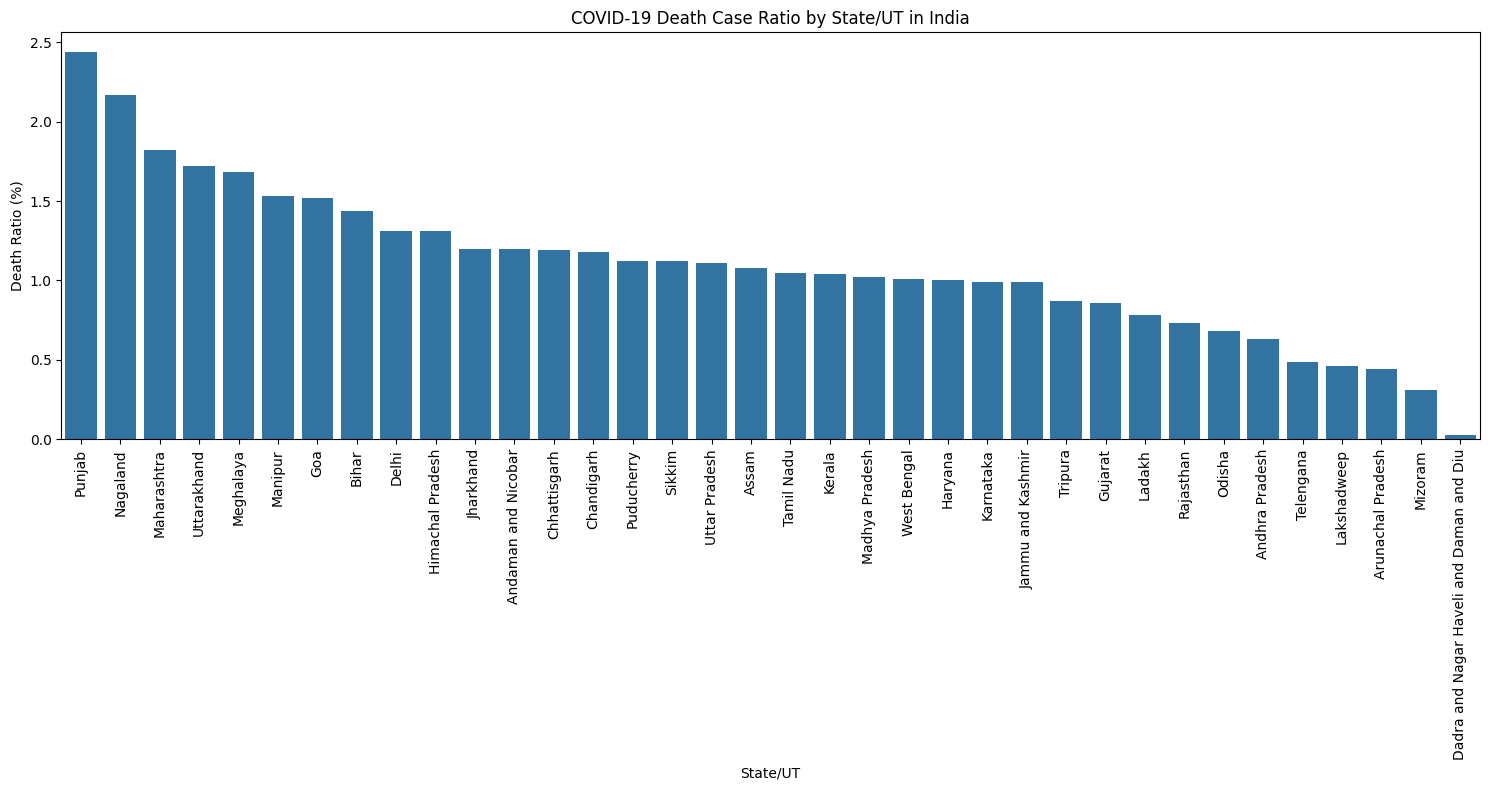

In [9]:
# The 'Death Ratio' column already exists and provides the death case ratio.
# Let's sort the DataFrame by 'Death Ratio' to see which states have the highest ratios.
df_sorted_by_death_ratio = df.sort_values(by='Death Ratio', ascending=False)

# Display the top states by Death Ratio
print("Top 10 States/UTs by Death Ratio:")
display(df_sorted_by_death_ratio[['State/UTs', 'Total Cases', 'Deaths', 'Death Ratio']].head(10))

# Visualize the Death Ratio
plt.figure(figsize=(15, 8))
sns.barplot(x='State/UTs', y='Death Ratio', data=df_sorted_by_death_ratio)
plt.xticks(rotation=90)
plt.title('COVID-19 Death Case Ratio by State/UT in India')
plt.xlabel('State/UT')
plt.ylabel('Death Ratio (%)')
plt.tight_layout()
plt.show()

### Population vs. Total Cases (Scatter Plot)

Now, let's visualize the relationship between the 'Population' of each state and its 'Total Cases' using a scatter plot. This will help us identify if more populated states tend to have higher total cases.

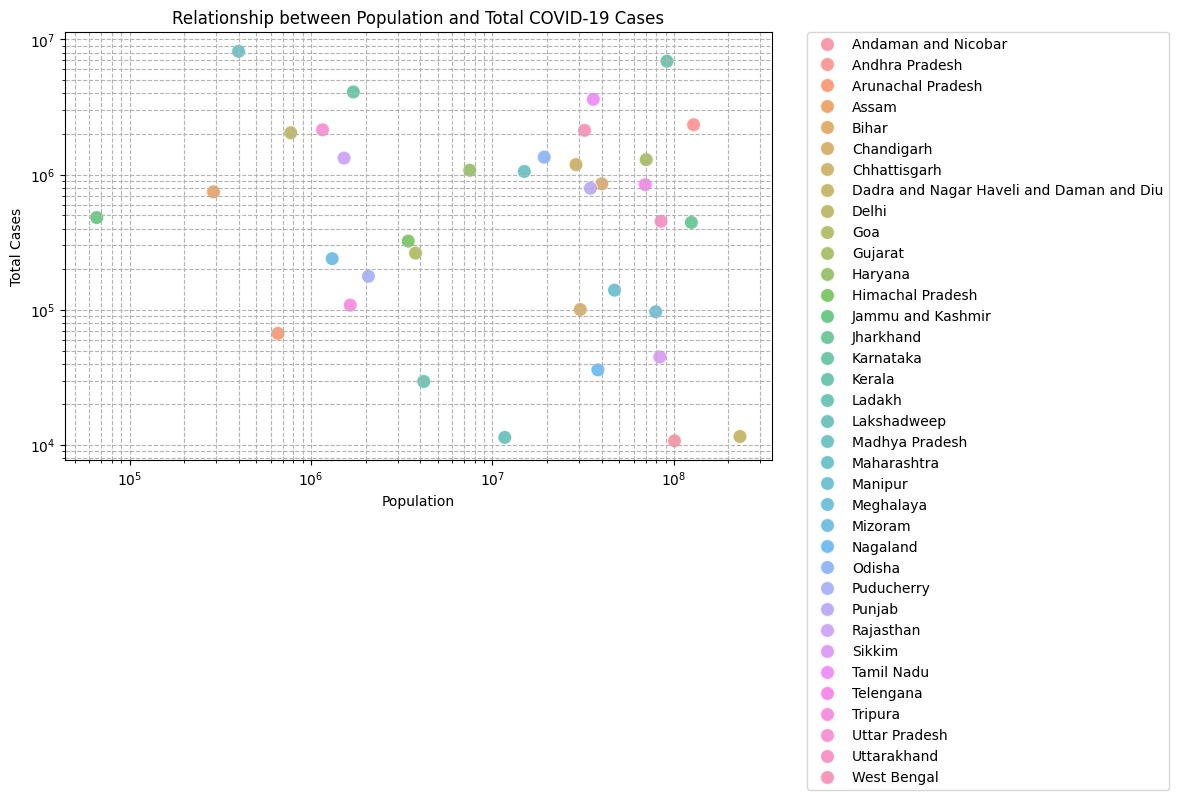

In [10]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Population', y='Total Cases', data=df, hue='State/UTs', s=100, alpha=0.7)
plt.title('Relationship between Population and Total COVID-19 Cases')
plt.xlabel('Population')
plt.ylabel('Total Cases')
plt.xscale('log') # Use a log scale for population if there's a wide range
plt.yscale('log') # Use a log scale for total cases if there's a wide range
plt.grid(True, which="both", ls="--", c='0.7')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

### Next Steps: Time-Series Data for Trends

As previously discussed, the current dataset provides a static snapshot of COVID-19 data. To fulfill the requirement of visualizing cases/deaths **trends** and using **date-time formatting**, we need a dataset that contains daily or weekly COVID-19 data over a period.

I will now proceed to search for a suitable time-series COVID-19 dataset for India. Once found, we can then perform trend analysis and visualize the cases/deaths over time.

In [12]:
import kagglehub

# Direct download of a known time-series COVID-19 dataset for India
# This dataset is known to contain daily time-series data for India.
time_series_path = kagglehub.dataset_download('sudalairajkumar/covid19-in-india')

print(f"Time-series dataset downloaded to: {time_series_path}")

100%|██████████| 758k/758k [00:00<00:00, 52.8MB/s]

Extracting files...
Time-series dataset downloaded to: /root/.cache/kagglehub/datasets/sudalairajkumar/covid19-in-india/versions/237


In [13]:
import os

# List files in the downloaded time-series path
time_series_files = os.listdir(time_series_path)
print("Files in the time-series dataset directory:", time_series_files)

Files in the time-series dataset directory: ['covid_vaccine_statewise.csv', 'covid_19_india.csv', 'StatewiseTestingDetails.csv']


In [15]:
import pandas as pd

# Assuming 'covid_19_india.csv' is the relevant file for time-series data
time_series_csv_name = 'covid_19_india.csv'
full_time_series_path = os.path.join(time_series_path, time_series_csv_name)

# Load the time-series dataset
df_time_series = pd.read_csv(full_time_series_path)

# Display the first 5 rows and info of the time-series DataFrame
display(df_time_series.head())
df_time_series.info()

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB


In [16]:
# Re-load the time-series dataset with the corrected file name
full_time_series_path = os.path.join(time_series_path, 'covid_19_india.csv')
df_time_series = pd.read_csv(full_time_series_path)

# Display the first 5 rows and info of the time-series DataFrame
display(df_time_series.head())
df_time_series.info()

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Sno                       18110 non-null  int64 
 1   Date                      18110 non-null  object
 2   Time                      18110 non-null  object
 3   State/UnionTerritory      18110 non-null  object
 4   ConfirmedIndianNational   18110 non-null  object
 5   ConfirmedForeignNational  18110 non-null  object
 6   Cured                     18110 non-null  int64 
 7   Deaths                    18110 non-null  int64 
 8   Confirmed                 18110 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.2+ MB


### Preprocessing Time-Series Data

To analyze trends, we need to convert the 'Date' column to datetime objects and ensure numerical columns are correctly typed. We'll also calculate daily new cases and deaths.

In [20]:
# Convert 'Date' column to datetime objects
df_time_series['Date'] = pd.to_datetime(df_time_series['Date'])

# Some columns are loaded as objects, let's convert them to numeric, handling errors
def convert_to_numeric_robust(df, column_name):
    # Convert column to numeric, coercing errors to NaN
    df[column_name] = pd.to_numeric(df[column_name], errors='coerce')
    # Fill NaN values with 0 (or another appropriate value if needed)
    df[column_name] = df[column_name].fillna(0)
    return df

# Convert 'ConfirmedIndianNational' and 'ConfirmedForeignNational' to numeric
df_time_series = convert_to_numeric_robust(df_time_series, 'ConfirmedIndianNational')
df_time_series = convert_to_numeric_robust(df_time_series, 'ConfirmedForeignNational')

# Check the info again to confirm data types
df_time_series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Sno                       18110 non-null  int64         
 1   Date                      18110 non-null  datetime64[ns]
 2   Time                      18110 non-null  object        
 3   State/UnionTerritory      18110 non-null  object        
 4   ConfirmedIndianNational   18110 non-null  float64       
 5   ConfirmedForeignNational  18110 non-null  float64       
 6   Cured                     18110 non-null  int64         
 7   Deaths                    18110 non-null  int64         
 8   Confirmed                 18110 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 1.2+ MB


### Daily Trend Visualization for All India

Now let's aggregate the data to get daily total confirmed cases, cured, and deaths for all of India and visualize their trends over time.

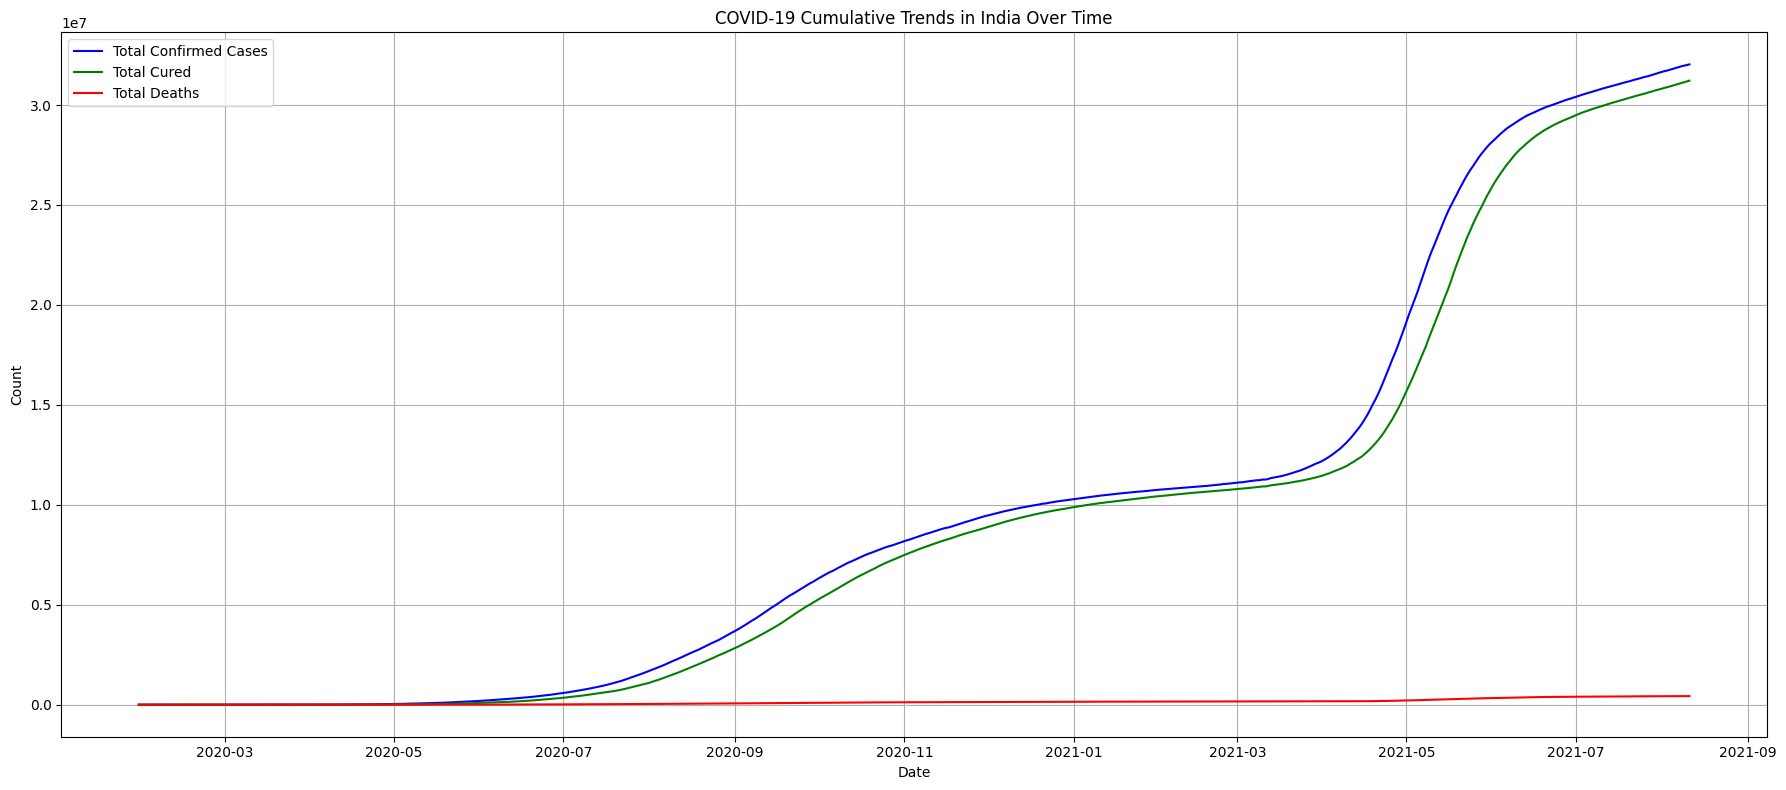

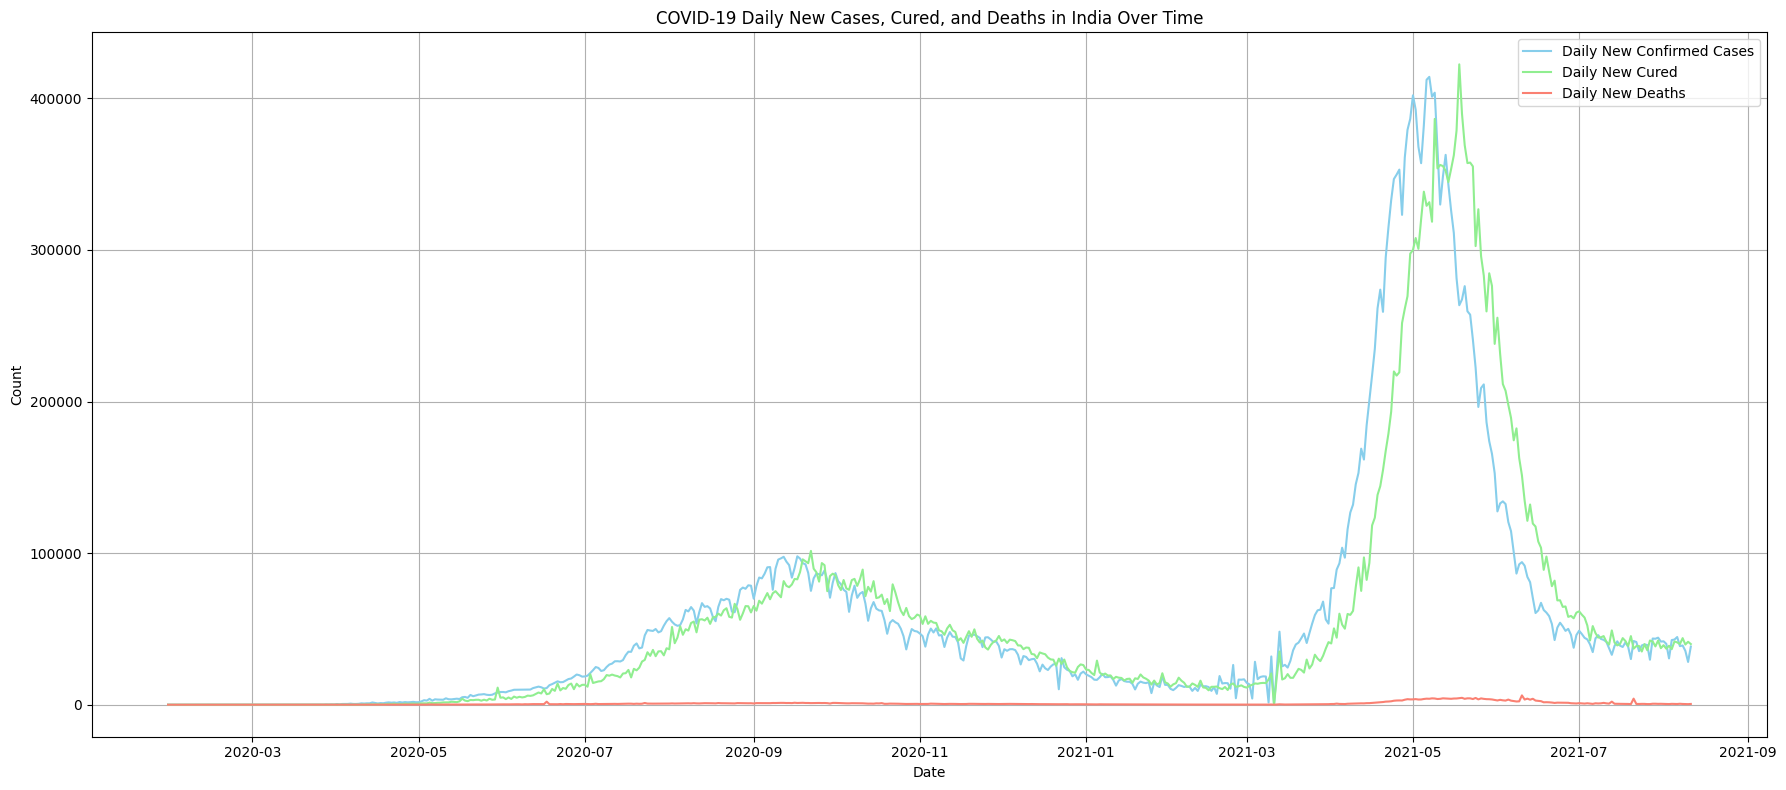

In [18]:
# Aggregate data by Date for India totals
india_daily = df_time_series.groupby('Date')[['Confirmed', 'Cured', 'Deaths']].sum().reset_index()

# Calculate daily new cases, cured, and deaths
india_daily['Daily Confirmed'] = india_daily['Confirmed'].diff().fillna(0)
india_daily['Daily Cured'] = india_daily['Cured'].diff().fillna(0)
india_daily['Daily Deaths'] = india_daily['Deaths'].diff().fillna(0)

# Ensure daily counts are non-negative (can happen due to data inconsistencies)
for col in ['Daily Confirmed', 'Daily Cured', 'Daily Deaths']:
    india_daily[col] = india_daily[col].apply(lambda x: max(0, x))

# Plotting total confirmed, cured, and deaths over time for India
plt.figure(figsize=(18, 8))
plt.plot(india_daily['Date'], india_daily['Confirmed'], label='Total Confirmed Cases', color='blue')
plt.plot(india_daily['Date'], india_daily['Cured'], label='Total Cured', color='green')
plt.plot(india_daily['Date'], india_daily['Deaths'], label='Total Deaths', color='red')
plt.title('COVID-19 Cumulative Trends in India Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting daily new confirmed, cured, and deaths over time for India
plt.figure(figsize=(18, 8))
plt.plot(india_daily['Date'], india_daily['Daily Confirmed'], label='Daily New Confirmed Cases', color='skyblue')
plt.plot(india_daily['Date'], india_daily['Daily Cured'], label='Daily New Cured', color='lightgreen')
plt.plot(india_daily['Date'], india_daily['Daily Deaths'], label='Daily New Deaths', color='salmon')
plt.title('COVID-19 Daily New Cases, Cured, and Deaths in India Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()